# Transferarbeit Data Science: Churn-Prognose für eine Retention-Kampagne

**Modul:** Data Science · **Dozent:** Stephan Kessler  
**Student:** Lennard Bernet · **Abgabe:** `DSC_TA_Bernet_Lennard.ipynb`  
**Datensatz:** Telco Customer Churn (~7'000 Kunden, 21 Merkmale)

---

Ein Telekommunikationsanbieter hat nur ein begrenztes Budget, um Kunden vom Kündigen abzuhalten (Retention-Budget). Gesucht ist deshalb ein Modell, das möglichst viele der Kunden findet, die kündigen werden. So gehen die Halteangebote an die richtigen Kunden.

Verwendet wird der Telco Customer Churn Datensatz. Er wurde von IBM synthetisch erzeugt und enthält keine echten Kundendaten.

Das Notebook ist nach den vier Blöcken aus dem Auftrag aufgebaut.

---
## 0 Setup

Alle Bibliotheken werden hier an einer Stelle importiert. Der feste `RANDOM_STATE` sorgt dafür, dass bei jedem Durchlauf die gleichen Resultate herauskommen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

---
# Block 1: Use-Case-Analyse

## 1.1 Beschreibung des Datensatzes
**Quelle:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Die Originaldatei `WA_Fn-UseC_-Telco-Customer-Churn.csv` liegt im gleichen Verzeichnis.

>Insgesamt hat der Datensatz 7043 Reihen und 21 Spalten.

Jede Reihe repräsentiert einen Kunden. In den Spalten sind jeweils Attribute zu diesem Kunde vorhanden. Man sieht welche Services die Kunden jeweils beim Telefonanbieter haben. Ebenfalls enthalten sind Informationen wie lange der Kunde schon beim Anbieter ist und was für ein Vertrag vorliegt. Demografische Daten wie das Geschlecht, ob es alte Menschen sind, und ob sie ein Partner haben gibt es auch. Die letzte Spalte sagt noch aus, ob der Kunde im letzten Monat gekündigt hat oder nicht.

## 1.2 Business-Frage

**«Welche Bestandskunden werden im kommenden Abrechnungszyklus kündigen und sollen deshalb ein
Halteangebot erhalten?»**

Mit der Spalte "Churn" hat man einen Datensatz mit dem die Kündigungen sauber dokumentiert sind. Die anderen Spalten sind Merkmale, die schon vor der Kündigung bekannt sind. Man hat jedoch keine genauen Informationen zu den Produktdaten, Netzqualität oder Preiselastizität. 
Somit hat man mit den gegebenen Daten eigentlich nur die Möglichkeit eine Vorhersage zu treffen, bei welchen Kunden im kommenden Abrechnungszyklus eine Kündigung am wahrscheinlichsten ist. 
Als Massnahme bleibt allein ein Halteangebot an die gefährdeten Kunden. So ein Angebot kostet Geld und muss einzeln vergeben werden. Die eigentliche Aufgabe ist daher die Priorisierung. Ein übersehener Kündiger ist als Kunde verloren, ein überflüssiges Angebot kostet lediglich den Rabatt.

## 1.3 Problemart und Begründung

Es handelt sich um eine binäre Klassifikation im überwachten Lernen.

Die Zielvariable `Churn` hat genau zwei Ausprägungen. Nämlich `Yes` und `No` und ist in den Daten so beschriftet.
Damit ist das Kriterium für überwachtes Lernen erfüllt. Das Modell lernt aus Beispielen, zu denen die richtige Antwort bekannt ist.
Eine Regression kommt nicht in Frage, da keine stetige Zielgrösse vorhergesagt werden soll.
Ein Clustering-Verfahren wie K-Means eignet sich ebenfalls nicht. Das arbeitet ohne Labels und Gruppen die selbstständig entdeckt werden. Hier kennt man diese Gruppe aber schon anhand von `Churn`.
Es wird auch nicht nur eine Klassenzuordnung sondern auch eine Wahrscheinlichkeit benötigt. Nur damit lässt sich schlussendlich eine gute Rangliste für die Priorität bilden um das begrenzte Budget auf die gefährdetsten Kunden zu lenken.

## 1.4 Nutzen für das Unternehmen

Ein Halteangebot kostet eine Firma bedeutend weniger als die Neuakquisition eines Kunden. Akquisition heisst Werbung, Vertrieb, Startrabatte etc.
Ein Rabatt für einen bestehenden Kunden ist ein einmaliger, kalkulierbarer Abzug. Ein verlorener Kunde ist ein entgangener Umsatz den man so einfach nicht zurück bekommt.
Das Budget in der Firma ist begrenzt, also braucht es eine Rangliste anstatt einfach blindes Verteilen von Halteangeboten. Genau das liefert das Modell.
Ein übersehener Kündiger ist weg und nicht mehr korrigierbar, ein überflüssiges Angebot kostet nur den Rabatt.

```
Annahme Monatsumsatz eines Kunden:        CHF  60
Annahme Restlaufzeit nach Rettung:         12 Monate
→ Wert eines gehaltenen Kunden:           CHF 720

Annahme Halteangebot: 20 % Rabatt, 6 Monate
→ Kosten des Angebots:                    CHF  72
Verhältnis Nutzen zu Kosten:                10 : 1
```

Diese Zahlen sind nur mal grobe Annahmen, die tatsächlichen Umsätze werden in Block 2 aus den Daten ermittelt.

## 1.5 Risiken sowie ethische und technische Grenzen

1. **Diskriminierung:** `gender` und `SeniorCitizen` sind sensible Merkmale. Werden Angebote danach verteilt, werden Personen wegen etwas unterschiedlich behandelt, das sie nicht ändern können. Bei einem Rabatt ist das für die Betroffenen eher ein Vorteil, bei Preisen oder schlechteren Konditionen wäre es eine Benachteiligung. Die Vorhersage darf deshalb nur für Halteangebote verwendet werden.

2. **Korrelation ist nicht Kausalität:** Das Modell sagt, wer wahrscheinlich kündigt, aber nicht warum. Wenn Kunden mit Monatsvertrag oft kündigen, heisst das nicht, dass man sie in Jahresverträge drängen sollte. Ursachen wie Netzqualität, Störungen oder Konkurrenzangebote fehlen in den Daten. Das Modell taugt also nur zur Priorisierung.

3. **Data Leakage:** Informationen aus dem Testset dürfen nicht ins Training gelangen. Deshalb werden die Daten zuerst aufgeteilt und die Vorverarbeitung steckt in einer Pipeline, die nur auf den Trainingsdaten lernt. Die `customerID` hat keinen Inhalt und wird entfernt.

4. **Momentaufnahme:** Die Daten zeigen nur einen Zeitpunkt und sind synthetisch. Ändert sich der Markt, wird das Modell mit der Zeit schlechter und müsste neu trainiert werden. Die Methode ist übertragbar, die konkreten Zahlen nicht.

---
# Block 2: Datenprozessierung und explorative Datenanalyse

## 2.1 Import und erster Überblick

Die CSV-Datei liegt im gleichen Ordner und wird mit einem relativen Pfad geladen. Danach geben `shape`, `head()`, `info()` und `describe()` einen ersten Überblick über Grösse, Datentypen und Wertebereiche.

In [2]:
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print("Form des Datensatzes (Zeilen, Spalten):", df.shape)
df.head()

Form des Datensatzes (Zeilen, Spalten): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
display(df.describe())
display(df.describe(include=["object", "string"]))

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


**Interpretation des Überblicks**

- 7043 Kunden und 21 Spalten, keine leeren Felder. Jede `customerID` kommt nur einmal vor.
- `TotalCharges` ist als Text eingelesen, obwohl es ein Betrag ist. Es stehen also falsche Werte drin (wird in 2.2 bereinigt).
- `SeniorCitizen` ist 0/1, also eigentlich Ja/Nein. 16 % der Kunden sind Senioren.
- Im Schnitt zahlen die Kunden CHF 64.76 pro Monat. Die Annahme von CHF 60 aus 1.4 ist also realistisch und eher vorsichtig.
- 26.5 % der Kunden haben gekündigt (vor der Bereinigung). Es gibt also viel weniger Kündiger als Nicht-Kündiger.


### Prüfung der Risiken aus 1.5

Einige Risiken aus 1.5 werden hier kurz mit den Daten überprüft. Daraus ergeben sich die Entscheide für die Bereinigung.

In [5]:
# Risiko 1: Grösse und Kündigungsrate der Gruppen bei den sensiblen Merkmalen
churn_flag = df["Churn"].eq("Yes")

for col in ["gender", "SeniorCitizen"]:
    display(churn_flag.groupby(df[col]).agg(Anzahl="size", Kuendigungsrate="mean").round(3))

,Anzahl,Kuendigungsrate
gender,,
Female,3488,0.269
Male,3555,0.262


,Anzahl,Kuendigungsrate
SeniorCitizen,,
0,5901,0.236
1,1142,0.417


**Befund sensible Merkmale:**
- Frauen und Männer kündigen fast gleich oft (27 % und 26 %). `gender` hilft dem Modell also nicht und wird entfernt.
- Senioren kündigen viel öfter (42 % statt 24 %). Das Modell wird sie deshalb häufiger als Risiko einstufen.
- Es gibt nur 1142 Senioren. Für diese Gruppe ist das Modell darum unsicherer.

Median tenure je Vertragsart (Monate):
Contract
Month-to-month    12.0
One year          44.0
Two year          64.0
Name: tenure, dtype: float64


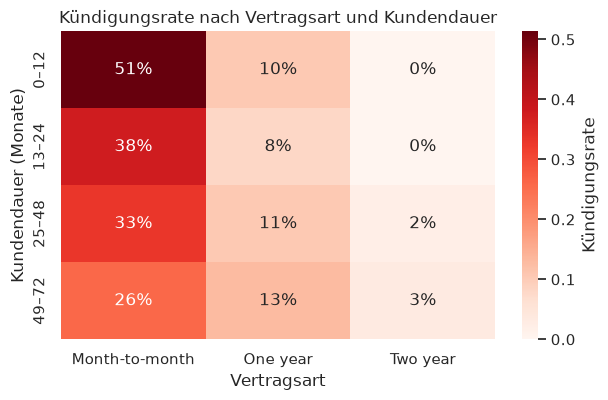

Contract,Month-to-month,One year,Two year
tenure,,,
0–12,1994,124,68
13–24,737,197,90
25–48,802,518,274
49–72,342,634,1263


In [6]:
# Risiko 2: Vertragsart und Kundendauer hängen zusammen (Korrelation ist nicht Kausalität)
print("Median tenure je Vertragsart (Monate):")
print(df.groupby("Contract")["tenure"].median())

tenure_bins = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                     labels=["0–12", "13–24", "25–48", "49–72"])
rate = pd.crosstab(tenure_bins, df["Contract"], values=churn_flag, aggfunc="mean")

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(rate, annot=True, fmt=".0%", cmap="Reds",
            cbar_kws={"label": "Kündigungsrate"}, ax=ax)
ax.set_title("Kündigungsrate nach Vertragsart und Kundendauer")
ax.set_xlabel("Vertragsart")
ax.set_ylabel("Kundendauer (Monate)")
plt.show()

# Anzahl Kunden je Feld: zeigt, wie belastbar die Raten oben sind
display(pd.crosstab(tenure_bins, df["Contract"]))

**Befund Korrelation und Kausalität:** Kunden mit Monatsvertrag kündigen am meisten, sind aber auch meistens
neu (Median 12 Monate). Auch bei gleicher Kundendauer kündigen sie öfter. Das heisst aber nicht, dass der
Vertrag die Ursache ist. Vielleicht wählen unsichere Kunden einfach von Anfang an keinen langen Vertrag.

In [7]:
# Risiko 3 und 4: technische Grenzen des Datensatzes
total = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Eindeutige customerID:", df["customerID"].nunique(), "von", len(df))
print("TotalCharges nicht numerisch:", total.isna().sum(), "Zeilen, tenure dort:",
      df.loc[total.isna(), "tenure"].unique())
print("Korrelation TotalCharges mit tenure * MonthlyCharges:",
      round(total.corr(df["tenure"] * df["MonthlyCharges"]), 4))

Eindeutige customerID: 7043 von 7043
TotalCharges nicht numerisch: 11 Zeilen, tenure dort: [0]
Korrelation TotalCharges mit tenure * MonthlyCharges: 0.9996


**Befund technische Grenzen:**
- `customerID` ist nur eine Nummer und wird entfernt.
- Die 11 fehlenden `TotalCharges` sind alles Neukunden (`tenure` = 0). Sie haben noch nichts bezahlt, es ist also kein Fehler.
- `TotalCharges` ist fast genau `tenure × MonthlyCharges`. Die Spalte bringt kaum neue Information und wird in 2.2 entfernt.
- Es gibt kein Datum. Man sieht also nicht, wie sich die Kunden über die Zeit verändern.

**Entscheid:** `gender` und `customerID` werden entfernt. `SeniorCitizen` bleibt drin, weil die Vorhersage nur für Halteangebote verwendet wird (siehe 1.5).

## 2.2 Qualitätsprüfung und begründete Bereinigung

Geprüft werden fehlende Werte, Dubletten und Ausreisser. Zu jedem Befund gibt es einen kurzen, begründeten
Entscheid. Am Schluss werden alle Bereinigungsschritte zusammen in einer Zelle ausgeführt.

In [8]:
# --- Fehlende Werte ---
print("Fehlende Werte laut isna():", df.isna().sum().sum())

# TotalCharges ist Text: Leerzeichen werden zu NaN, damit man sie zählen kann
total = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Leere TotalCharges:", total.isna().sum())
display(df.loc[total.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Fehlende Werte laut isna(): 0
Leere TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Entscheid fehlende Werte:** `isna()` findet nichts, weil in den leeren Feldern ein Leerzeichen steht.
Nach der Umwandlung in Zahlen sind es 11 Kunden. Alle haben `tenure` = 0, sind also ganz neu und haben
noch keine Rechnung bekommen. Es ist also kein Fehler.

Man könnte die Werte mit 0 auffüllen oder die Zeilen löschen. Die 11 Zeilen werden gelöscht, weil es nur ein sehr kleiner Teil der Daten ist und diese Kunden noch keine Vorgeschichte haben.

In [9]:
# --- Dubletten ---
print("Doppelte customerID:", df["customerID"].duplicated().sum())
print("Komplett gleiche Zeilen:", df.duplicated().sum())
print("Gleiche Zeilen ohne customerID:", df.drop(columns="customerID").duplicated().sum())

Doppelte customerID: 0
Komplett gleiche Zeilen: 0
Gleiche Zeilen ohne customerID: 22


**Befund Dubletten:** Kein Kunde kommt doppelt vor. Ohne die `customerID` sind 22 Zeilen gleich. Dass mehrere Kunden genau das gleiche Abo haben, ist normal. Es sind verschiedene Personen, deshalb bleiben sie drin.

,Min,Max,Untere Grenze,Obere Grenze,Ausreisser
tenure,0.0,72.0,-60.0,124.0,0
MonthlyCharges,18.2,118.8,-46.0,171.4,0
TotalCharges,18.8,8684.8,-4688.5,8884.7,0


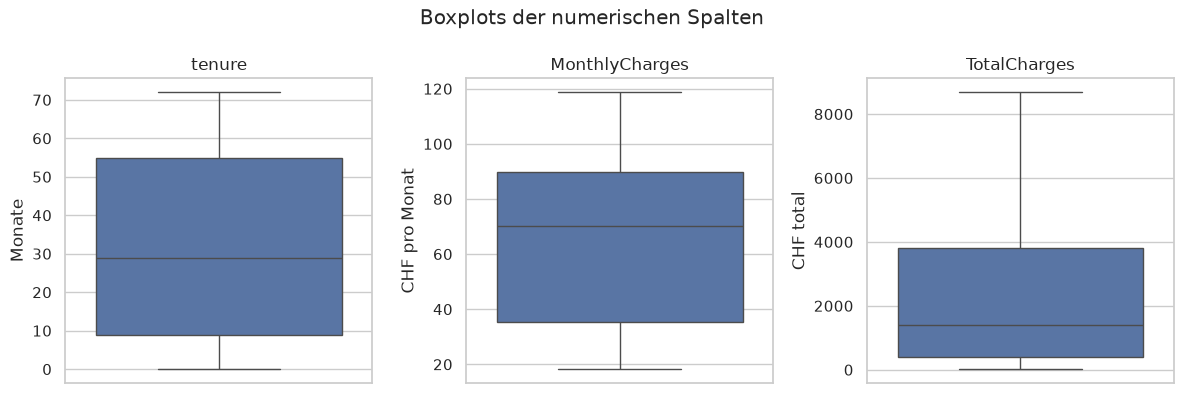

In [10]:
# --- Ausreisser (IQR-Regel) ---
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
num = df[num_cols].assign(TotalCharges=total)

q1 = num.quantile(0.25)
q3 = num.quantile(0.75)
iqr = q3 - q1
untere_grenze = q1 - 1.5 * iqr
obere_grenze = q3 + 1.5 * iqr
anzahl = ((num < untere_grenze) | (num > obere_grenze)).sum()

display(pd.DataFrame({"Min": num.min(), "Max": num.max(), "Untere Grenze": untere_grenze,
                      "Obere Grenze": obere_grenze, "Ausreisser": anzahl}).round(1))

einheit = {"tenure": "Monate", "MonthlyCharges": "CHF pro Monat", "TotalCharges": "CHF total"}
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=num[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel(einheit[col])
fig.suptitle("Boxplots der numerischen Spalten")
plt.tight_layout()
plt.show()

**Entscheid Ausreisser:** Nach der IQR-Regel gibt es keine Ausreisser, alle Werte liegen innerhalb der
Grenzen. Die Werte sind auch realistisch: 0–72 Monate und CHF 18–119 pro Monat. Hohe `TotalCharges` gehören
zu Kunden, die schon lange dabei sind. Es wird nichts entfernt.

In [11]:
# --- Bereinigung (auf einer Kopie, df bleibt im Rohzustand) ---
df_clean = df.copy()

# 1. TotalCharges in Zahlen umwandeln und die 11 Neukunden ohne Rechnung löschen
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean = df_clean.dropna(subset=["TotalCharges"])

# 2. SeniorCitizen von 0/1 in No/Yes umwandeln, wie die anderen Ja/Nein-Spalten
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({0: "No", 1: "Yes"})

# 3. customerID, gender und TotalCharges entfernen (Entscheid aus 2.1)
df_clean = df_clean.drop(columns=["customerID", "gender", "TotalCharges"])

print("Vorher:", df.shape, " Nachher:", df_clean.shape)
df_clean.info()

Vorher: (7043, 21)  Nachher: (7032, 18)
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7032 non-null   str    
 1   Partner           7032 non-null   str    
 2   Dependents        7032 non-null   str    
 3   tenure            7032 non-null   int64  
 4   PhoneService      7032 non-null   str    
 5   MultipleLines     7032 non-null   str    
 6   InternetService   7032 non-null   str    
 7   OnlineSecurity    7032 non-null   str    
 8   OnlineBackup      7032 non-null   str    
 9   DeviceProtection  7032 non-null   str    
 10  TechSupport       7032 non-null   str    
 11  StreamingTV       7032 non-null   str    
 12  StreamingMovies   7032 non-null   str    
 13  Contract          7032 non-null   str    
 14  PaperlessBilling  7032 non-null   str    
 15  PaymentMethod     7032 non-null   str    
 16  MonthlyCharges    

**Ergebnis:** Übrig bleiben 7032 Kunden und 18 Spalten ohne fehlende Werte. `TotalCharges` wurde nur noch
gebraucht, um die 11 Neukunden zu finden, und ist jetzt entfernt (fast genau `tenure × MonthlyCharges`, siehe 2.1).
`SeniorCitizen` ist Yes/No wie die anderen Ja/Nein-Spalten. Ab hier wird mit `df_clean` gearbeitet.

## 2.3 Explorative Datenanalyse

Fünf Grafiken, die je eine Frage beantworten: Wie viele Kunden kündigen? Wann kündigen sie? Welche Rolle
spielt die Vertragsart? Wie hängen Kundendauer und Preis zusammen?
Und hängen Zusatzdienste mit Kündigungen zusammen?

### Visualisierung 1: Verteilung der Zielvariable

Wie viele Kunden kündigen, und wie viele bleiben?

       Anzahl  Prozent
Churn                 
No       5163     73.4
Yes      1869     26.6


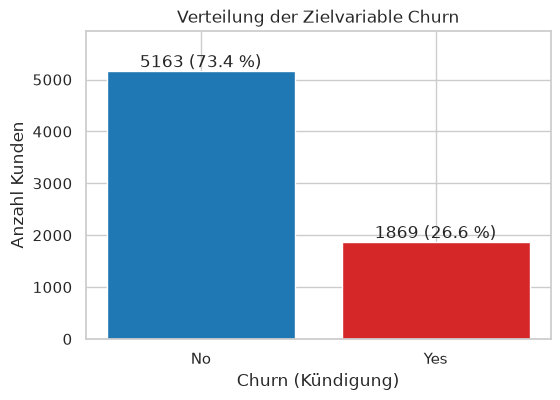

In [12]:
# Visualisierung 1: Verteilung der Zielvariable
anzahl = df_clean["Churn"].value_counts()
prozent = df_clean["Churn"].value_counts(normalize=True) * 100
print(pd.DataFrame({"Anzahl": anzahl, "Prozent": prozent.round(1)}))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(anzahl.index, anzahl.values, color=["tab:blue", "tab:red"])
for i, (n, p) in enumerate(zip(anzahl, prozent)):
    ax.text(i, n, f"{n} ({p:.1f} %)", ha="center", va="bottom")
ax.set_ylim(0, anzahl.max() * 1.15)
ax.set_title("Verteilung der Zielvariable Churn")
ax.set_xlabel("Churn (Kündigung)")
ax.set_ylabel("Anzahl Kunden")
plt.show()

**Interpretation:** Die Grafik zeigt, dass die beiden Gruppen sehr ungleich gross sind. 5163 Kunden (73.4 %) bleiben, nur 1869 Kunden (26.6 %) kündigen. Auf einen Kündiger kommen also fast drei Kunden, die bleiben. Die Kündiger sind damit klar die kleinere Gruppe.

### Visualisierung 2: Kundendauer (`tenure`) nach Churn

Wann kündigen die Kunden?

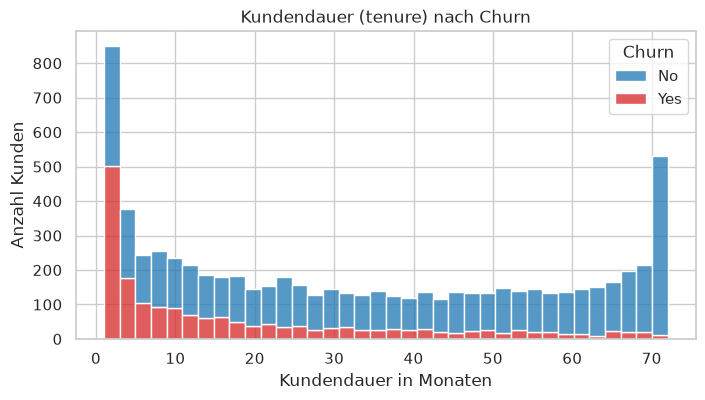

Kündigungen im ersten Jahr: 55.5% aller Kündigungen


In [13]:
# Visualisierung 2: Kundendauer nach Churn
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_clean, x="tenure", hue="Churn", bins=36, multiple="stack",
             palette={"No": "tab:blue", "Yes": "tab:red"}, ax=ax)
ax.set_title("Kundendauer (tenure) nach Churn")
ax.set_xlabel("Kundendauer in Monaten")
ax.set_ylabel("Anzahl Kunden")
plt.show()

# Anteil der Kündiger, die im ersten Jahr kündigen
kuendiger = df_clean[df_clean["Churn"] == "Yes"]
print(f"Kündigungen im ersten Jahr: {(kuendiger['tenure'] <= 12).mean():.1%} aller Kündigungen")

**Interpretation:** Die meisten Kündigungen passieren ganz am Anfang. 55.5 % aller Kündiger gehen schon im
ersten Jahr. Wer lange dabei ist, kündigt kaum noch.

### Visualisierung 3: Kündigungsrate nach Vertragsart (`Contract`)

Wie oft kündigen Kunden je nach Vertrag?

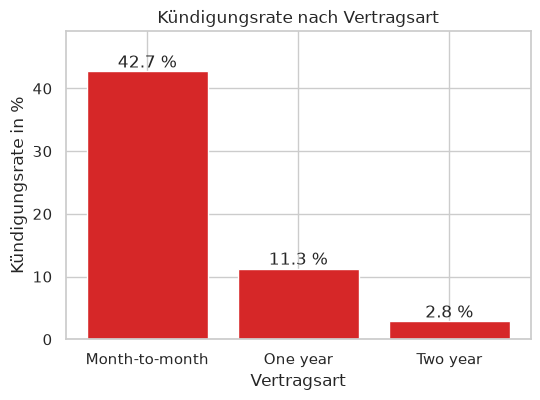

In [14]:
# Visualisierung 3: Kündigungsrate je Vertragsart
rate_contract = (df_clean["Churn"] == "Yes").groupby(df_clean["Contract"]).mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(rate_contract.index, rate_contract.values, color="tab:red")
for i, r in enumerate(rate_contract):
    ax.text(i, r, f"{r:.1f} %", ha="center", va="bottom")
ax.set_ylim(0, rate_contract.max() * 1.15)
ax.set_title("Kündigungsrate nach Vertragsart")
ax.set_xlabel("Vertragsart")
ax.set_ylabel("Kündigungsrate in %")
plt.show()

**Interpretation:** Kunden mit Monatsvertrag kündigen zu 42.7 %, bei 1-Jahres-Verträgen sind es 11.3 % und
bei 2-Jahres-Verträgen nur 2.8 %. Wie in 2.1
gezeigt, ist der Vertrag aber nicht sicher die Ursache. Man sieht nur, dass beides zusammen auftritt.

### Visualisierung 4: Kundendauer und Monatsgebühr zusammen

Wo liegen die Kündiger, wenn man Kundendauer und Preis gleichzeitig anschaut?

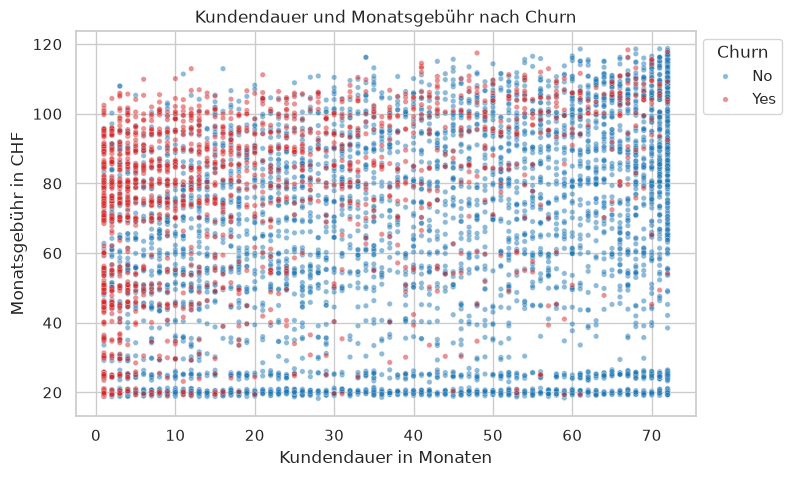

Neu und teuer: 873 Kunden, Kündigungsrate 68.0%
Alle übrigen:  6159 Kunden, Kündigungsrate 20.7%


In [15]:
# Visualisierung 4: Kundendauer und Monatsgebühr zusammen
fig, ax = plt.subplots(figsize=(8, 5))
# sortiert, damit die Kündiger (rot) oben liegen und sichtbar sind
sns.scatterplot(data=df_clean.sort_values("Churn"), x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.5, s=15,
                palette={"No": "tab:blue", "Yes": "tab:red"}, ax=ax)
ax.set_title("Kundendauer und Monatsgebühr nach Churn")
ax.set_xlabel("Kundendauer in Monaten")
ax.set_ylabel("Monatsgebühr in CHF")
ax.legend(title="Churn", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

# Kündigungsrate in der Ecke oben links: neu (max. 12 Monate) und teuer (über CHF 70)
neu_teuer = (df_clean["tenure"] <= 12) & (df_clean["MonthlyCharges"] > 70)
print(f"Neu und teuer: {neu_teuer.sum()} Kunden, Kündigungsrate {(df_clean.loc[neu_teuer, 'Churn'] == 'Yes').mean():.1%}")
print(f"Alle übrigen:  {(~neu_teuer).sum()} Kunden, Kündigungsrate {(df_clean.loc[~neu_teuer, 'Churn'] == 'Yes').mean():.1%}")

**Interpretation:** Die roten Punkte sammeln sich oben links, also bei Kunden, die neu sind und viel bezahlen.
Von diesen Kunden (max. 12 Monate, über CHF 70) kündigen 68 %, bei allen anderen nur 21 %. Unten rechts
(lange dabei, günstiges Abo) gibt es fast keine Kündiger. Man sieht auch waagrechte Linien bei ca. CHF 20,
das sind fast nur Kunden mit dem günstigsten Abo ohne Internet. Von ihnen kündigen nur etwa 9 %.

### Visualisierung 5: Kündigungsrate mit und ohne Zusatzdienst

Kündigen Kunden weniger, wenn sie Zusatzdienste gebucht haben? Betrachtet werden nur Kunden mit Internet,
weil nur sie diese Dienste buchen können.

                  ohne Dienst  mit Dienst
OnlineSecurity           41.8        14.6
OnlineBackup             39.9        21.6
DeviceProtection         39.1        22.5
TechSupport              41.6        15.2
StreamingTV              33.5        30.1
StreamingMovies          33.7        30.0


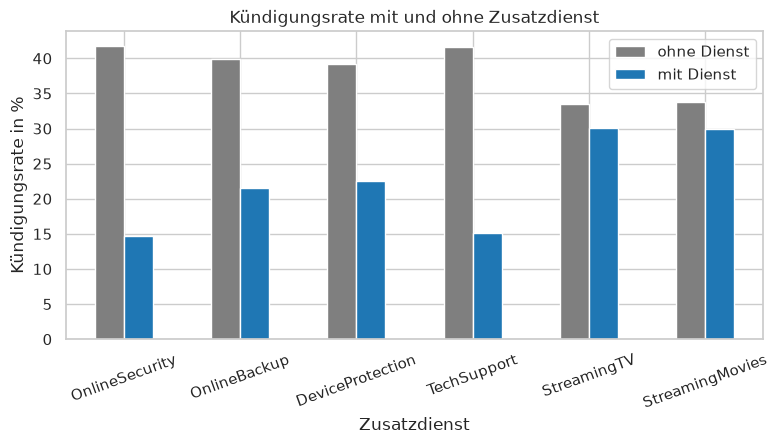

In [16]:
# Visualisierung 5: Kündigungsrate mit und ohne Zusatzdienst (nur Kunden mit Internet)
dienste = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
mit_internet = df_clean[df_clean["InternetService"] != "No"]

rate_dienste = pd.DataFrame({
    d: (mit_internet["Churn"] == "Yes").groupby(mit_internet[d]).mean() * 100 for d in dienste
}).T.rename(columns={"No": "ohne Dienst", "Yes": "mit Dienst"})
print(rate_dienste.round(1))

ax = rate_dienste.plot.bar(figsize=(9, 4), color=["tab:gray", "tab:blue"], rot=20)
ax.set_title("Kündigungsrate mit und ohne Zusatzdienst")
ax.set_xlabel("Zusatzdienst")
ax.set_ylabel("Kündigungsrate in %")
ax.legend(title="")
plt.show()

**Interpretation:** Bei den Diensten rund um Sicherheit und Support ist der Unterschied gross. Ohne
`OnlineSecurity` oder `TechSupport` kündigen rund 42 %, mit diesen Diensten nur etwa 15 %. Bei `OnlineBackup` und
`DeviceProtection` ist der Unterschied kleiner. Bei `StreamingTV` und `StreamingMovies` gibt es fast keinen
Unterschied (ca. 34 % zu 30 %). Nicht jeder Zusatzdienst hängt also gleich stark mit Kündigungen zusammen.

## 2.4 Feature Engineering

Drei neue Merkmale, die direkt aus den Beobachtungen in 2.3 entstehen.

**Feature 1: `neu_und_teuer` (Kombination)**

Yes, wenn ein Kunde höchstens 12 Monate dabei ist **und** mehr als CHF 70 pro Monat bezahlt. In
Visualisierung 4 war genau diese Ecke oben links voller Kündiger. In `tenure` oder
`MonthlyCharges` sieht man das nicht so direkt. Erst mit dieser Kombination im Feature ist dies richtig greifbar.

**Feature 2: `num_services` (Aggregation)**

Anzahl der gebuchten Zusatzdienste (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
`StreamingTV`, `StreamingMovies`). Es wird geprüft, ob man durch viele Dienste auch stärker am Anbieter gebunden ist. Die 6 Spalten werden so in einer einzigen Spalte mit einer Zahl zusammengefasst.

**Feature 3: `num_schutzdienste` (Aggregation)**

Anzahl der gebuchten Schutzdienste (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`).
Die Idee dieses Features kommt aus der Visualisierung 5. Dort sieht man ganz klar, dass diese Dienste einen stärkeren Zusammenhang mit der Kündigung haben. Deshalb werden diese in einem separatem Feature ausgewiesen.

In [17]:
# Feature 1: neu und teuer (aus Visualisierung 4)
df_clean["neu_und_teuer"] = np.where(
    (df_clean["tenure"] <= 12) & (df_clean["MonthlyCharges"] > 70), "Yes", "No")

# Feature 2: Anzahl gebuchter Zusatzdienste ('No internet service' zählt nicht)
dienste = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df_clean["num_services"] = (df_clean[dienste] == "Yes").sum(axis=1)

# Feature 3: Anzahl Schutzdienste (aus Visualisierung 5, ohne Streaming)
schutzdienste = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
df_clean["num_schutzdienste"] = (df_clean[schutzdienste] == "Yes").sum(axis=1)

df_clean[["tenure", "MonthlyCharges", "neu_und_teuer", "num_services", "num_schutzdienste"]].head()

,tenure,MonthlyCharges,neu_und_teuer,num_services,num_schutzdienste
0,1,29.85,No,1,1
1,34,56.95,No,2,2
2,2,53.85,No,2,2
3,45,42.30,No,3,3
4,2,70.70,Yes,0,0


In [18]:
# Unterscheiden die neuen Features zwischen Kündigern und Bleibenden?
kuendigt = df_clean["Churn"] == "Yes"

print("Kündigungsrate je neu_und_teuer:")
display(kuendigt.groupby(df_clean["neu_und_teuer"]).agg(Anzahl="size", Kuendigungsrate="mean").round(3))

print("Durchschnittliche Anzahl Zusatzdienste je Churn:")
display(df_clean.groupby("Churn")["num_services"].mean().round(2))

print("Kündigungsrate je Anzahl Zusatzdienste:")
display(kuendigt.groupby(df_clean["num_services"]).agg(Anzahl="size", Kuendigungsrate="mean").round(3))

# Nur Kunden mit Internet, weil die anderen gar keine Schutzdienste buchen können
mit_internet = df_clean["InternetService"] != "No"
print("Kündigungsrate je Anzahl Schutzdienste (nur Kunden mit Internet):")
display(kuendigt[mit_internet].groupby(df_clean.loc[mit_internet, "num_schutzdienste"])
        .agg(Anzahl="size", Kuendigungsrate="mean").round(3))

Kündigungsrate je neu_und_teuer:


,Anzahl,Kuendigungsrate
neu_und_teuer,,
No,6159,0.207
Yes,873,0.680


Durchschnittliche Anzahl Zusatzdienste je Churn:


Churn
No     2.14
Yes    1.77
Name: num_services, dtype: float64

Kündigungsrate je Anzahl Zusatzdienste:


,Anzahl,Kuendigungsrate
num_services,,
0,2213,0.215
1,966,0.458
2,1033,0.358
3,1117,0.274
4,850,0.224
5,569,0.125
6,284,0.053


Kündigungsrate je Anzahl Schutzdienste (nur Kunden mit Internet):


,Anzahl,Kuendigungsrate
num_schutzdienste,,
0,1267,0.567
1,1467,0.389
2,1372,0.238
3,937,0.125
4,469,0.053


**Interpretation:**
- **`neu_und_teuer`:** 873 Kunden fallen in diese Gruppe, und von ihnen kündigen 68 %. Bei allen anderen sind es
  nur 21 %. Das Feature trennt die Gruppen also deutlich.
- **`num_services`:** Kündiger haben im Schnitt weniger Dienste (1.8 statt 2.1). Ab einem Dienst gilt: Je mehr
  Dienste, desto weniger Kündigungen (1 Dienst: 46 %, 6 Dienste: 5 %). Bei 0 Diensten ist die Rate tiefer (22 %),
  weil dort viele Kunden ohne Internet dabei sind, die generell selten kündigen.

- **`num_schutzdienste`:** Bei Kunden mit Internet sinkt die Kündigungsrate mit jedem Schutzdienst gleichmässig:
  ohne Schutzdienst 57 %, mit allen vier nur 5 %. Das Muster ist klarer als bei `num_services`, weil die
  Streaming-Dienste, die kaum etwas aussagen, nicht mitgezählt werden.

Alle drei Features kommen ins Modell. Das Codieren und Skalieren der Spalten ist kein neues Feature, sondern nur eine technische Umformung, und folgt deshalb erst in 3.2.

## 2.5 Train/Test-Split

Die Daten werden in einen Trainingsteil (80 %) und einen Testteil (20 %) aufgeteilt. Das Modell lernt nur mit
den Trainingsdaten, die Testdaten bleiben bis Block 4 unberührt. So kann man am Schluss ehrlich prüfen, wie
gut das Modell bei Kunden ist, die es noch nie gesehen hat.

Der Split kommt **vor** dem Skalieren und Codieren. Sonst würden Informationen aus den Testdaten ins Training
rutschen (Data Leakage). Mit `stratify=y` haben beide Teile den gleichen Anteil an Kündigern.

In [19]:
# Zielvariable als 0/1 (1 = Kündigung) und Merkmale getrennt
y = (df_clean["Churn"] == "Yes").astype(int)
X = df_clean.drop(columns="Churn")

# 80 % Training, 20 % Test, mit gleichem Anteil an Kündigern in beiden Teilen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Training:", X_train.shape, " Test:", X_test.shape)
print(f"Anteil Kündiger im Training: {y_train.mean():.1%}")
print(f"Anteil Kündiger im Test:     {y_test.mean():.1%}")

Training: (5625, 20)  Test: (1407, 20)
Anteil Kündiger im Training: 26.6%
Anteil Kündiger im Test:     26.6%


**Ergebnis:** 5625 Kunden im Training und 1407 im Test, mit je 20 Merkmalen. In beiden Teilen kündigen 26.6 %,
das Verhältnis aus Visualisierung 1 bleibt also gleich. `customerID`, `gender` und `TotalCharges` wurden schon in 2.2 entfernt.

---
# Block 3: Modellwahl und Training

## 3.1 Auswahl der beiden Modelle

Gewählt werden zwei Modelle, die ganz unterschiedlich funktionieren.

**Logistische Regression** Dieses Modell gibt für jeden Kunden eine Kündigungswahrscheinlichkeit aus und die Kunden können nach Risiko sortiert werden. Es wird jedes Merkmal gewichtet und daraus eine Wahrscheinlichkeit berechnet. Es erkennt aber auch nur lineare Zusammenhänge was das ganze etwas einschränkt.

**Entscheidungsbaum**
Es werden nacheinander Ja/Nein-Fragen an die Daten gefragt. Die Daten werden also Schritt für Schritt aufgeteilt. Somit wird versucht die Kombinationen zu finden der Merkmale, die zu einer Kündigung führen. Ohne Grenze wächst der Baum, bis er die Trainingsdaten auswendig kennt was zu einem sogenannten Overfitting führt.

## 3.2 Daten vorbereiten (Pipeline)

Modelle rechnen nur mit Zahlen. Deshalb:

- **Zahlen-Spalten** (`tenure`, `MonthlyCharges`, `num_services`, `num_schutzdienste`) → `StandardScaler`: alle auf die gleiche Skala (Mittelwert 0, Streuung 1).
- **Text-Spalten** (alle übrigen) → `OneHotEncoder`: pro Kategorie eine 0/1-Spalte. Kein Durchnummerieren, weil sonst eine Reihenfolge entstehen würde, die es nicht gibt.

Beides steckt in einem `ColumnTransformer` in der Pipeline. Die Vorbereitung lernt so nur aus den Trainingsdaten (kein Data Leakage), wird aber beim Vorhersagen genau gleich auch auf das Testset angewendet.

In [20]:
# Spalten aufteilen: Zahlen bleiben Zahlen, alles andere ist Text
num_features = ["tenure", "MonthlyCharges", "num_services", "num_schutzdienste"]
cat_features = [col for col in X_train.columns if col not in num_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), cat_features),
])

print("Zahlen-Spalten:", len(num_features), num_features)
print("Text-Spalten:  ", len(cat_features), cat_features)
print("Spalten vor der Vorbereitung:", X_train.shape[1])
print("Spalten nach der Vorbereitung:", preprocessor.fit_transform(X_train).shape[1])

Zahlen-Spalten: 4 ['tenure', 'MonthlyCharges', 'num_services', 'num_schutzdienste']
Text-Spalten:   16 ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'neu_und_teuer']
Spalten vor der Vorbereitung: 20


Spalten nach der Vorbereitung: 41


In [21]:
# Welche Spalten entstehen dabei? Jede neue Spalte ihrer Ursprungsspalte zuordnen
neue_namen = pd.Series(preprocessor.get_feature_names_out()).str.split("__", n=1).str[1]
ursprung = [max((col for col in X_train.columns if name == col or name.startswith(col + "_")), key=len)
            for name in neue_namen]

uebersicht = (pd.DataFrame({"Ursprungsspalte": ursprung, "neue Spalte": neue_namen})
              .groupby("Ursprungsspalte", sort=False)["neue Spalte"]
              .agg(Anzahl="size", Spalten=lambda s: ", ".join(s)))
print(uebersicht.to_string())

                   Anzahl                                                                                                                                     Spalten
Ursprungsspalte                                                                                                                                                      
tenure                  1                                                                                                                                      tenure
MonthlyCharges          1                                                                                                                              MonthlyCharges
num_services            1                                                                                                                                num_services
num_schutzdienste       1                                                                                                                           num_schutzdienste
Seni

In [22]:
# Wie sehen die Daten konkret aus? Die ersten 3 Kunden vorher und nachher
X_train_prep = pd.DataFrame(preprocessor.transform(X_train), columns=neue_namen, index=X_train.index)

print("Vorher (Originaldaten):")
display(X_train.head(3))
print("Nachher (skaliert und codiert):")
display(X_train_prep.head(3).round(2))

Vorher (Originaldaten):


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,neu_und_teuer,num_services,num_schutzdienste
1413,No,Yes,Yes,65,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),94.55,No,4,4
7003,No,No,No,26,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,35.75,No,2,2
3355,No,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),90.20,No,3,3


Nachher (skaliert und codiert):


,tenure,MonthlyCharges,num_services,num_schutzdienste,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,neu_und_teuer_Yes
1413,1.32,0.98,1.05,2.11,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
7003,-0.27,-0.97,-0.03,0.56,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3355,1.44,0.84,0.51,1.34,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


**Ergebnis:** Aus den 20 Spalten werden 41. Die vier Zahlen-Spalten bleiben je eine Spalte und werden nur skaliert. Zum Beispiel wird `tenure` = 65 Monate zu 1.32, der Kunde ist also deutlich länger dabei als der Durchschnitt.

Bei den Text-Spalten hängt es von der Anzahl Kategorien ab:
- Ja/Nein-Spalten brauchen dank `drop="if_binary"` nur eine 0/1-Spalte (z. B. `Partner_Yes`).
- Spalten mit drei Kategorien werden zu drei Spalten (`Contract_Month-to-month`, `Contract_One year`, `Contract_Two year`), `PaymentMethod` mit vier Zahlungsarten zu vier.

Pro Kunde steht in genau einer dieser Spalten eine 1, im Beispiel oben bei `Contract_Two year`. Der `preprocessor` wird in beide Pipelines eingebaut und lernt dort nur aus den Trainingsdaten.

## 3.3 Modell A: Logistische Regression

Die logistische Regression wird zuerst mit den Standard-Einstellungen trainiert. Vorbereitung und Modell stecken zusammen in einer Pipeline, damit die Vorbereitung nur aus den Trainingsdaten lernt.

Bewertet wird mit 5-facher Kreuzvalidierung: Die Trainingsdaten werden in 5 Teile geteilt, das Modell lernt jeweils mit 4 Teilen und wird am übrigen Teil getestet. Das Testset bleibt dabei unberührt.

In [23]:
# Modell A: Vorbereitung und logistische Regression zusammen in einer Pipeline
logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

# 5-fache Kreuzvalidierung auf den Trainingsdaten (Testset bleibt unberührt)
print("5-fache Kreuzvalidierung auf den Trainingsdaten:")
for metrik in ["recall", "precision", "accuracy"]:
    werte = cross_val_score(logreg, X_train, y_train, cv=5, scoring=metrik)
    print(f"  {metrik:10s} Mittelwert {werte.mean():.3f}   Einzelwerte {np.round(werte, 3)}")

5-fache Kreuzvalidierung auf den Trainingsdaten:


  recall     Mittelwert 0.535   Einzelwerte [0.528 0.542 0.532 0.508 0.565]


  precision  Mittelwert 0.654   Einzelwerte [0.608 0.695 0.66  0.633 0.676]


  accuracy   Mittelwert 0.801   Einzelwerte [0.784 0.815 0.803 0.791 0.812]


**Ergebnis:** Das Modell findet nur 53.5 % der Kündiger (Recall), fast die Hälfte wird also übersehen. Von den als «kündigt» markierten Kunden kündigen 65.4 % wirklich (Precision). Die Accuracy von 80.1 % klingt gut, aber ein Modell, das immer «bleibt» sagt, hätte schon 73 %.

Weil es viel weniger Kündiger gibt, entscheidet sich das Modell im Zweifel für «bleibt». Die fünf Durchläufe liegen nah beieinander (Recall 0.51 bis 0.57), das Modell ist also stabil. Im Tuning (3.5) wird versucht, den Recall zu erhöhen.

## 3.4 Modell B: Entscheidungsbaum

Der Baum wird zuerst ohne Grenze trainiert. Er wächst dann so lange, bis in jedem Blatt nur noch Kunden einer Klasse sind. Um zu sehen, ob er dabei auswendig lernt (Overfitting), werden die Werte auf den Trainingsdaten mit denen aus der Kreuzvalidierung verglichen.

In [24]:
# Modell B: gleiche Vorbereitung, aber ein Entscheidungsbaum ohne Grenze
baum = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
baum.fit(X_train, y_train)

gewachsener_baum = baum.named_steps["model"]
print(f"Der Baum ist {gewachsener_baum.get_depth()} Fragen tief und hat {gewachsener_baum.get_n_leaves()} Blätter.\n")

# Einmal auf den bekannten Trainingskunden, einmal auf ungesehenen Kunden
vergleich = pd.DataFrame({
    "auf Trainingsdaten (kennt er)": [
        accuracy_score(y_train, baum.predict(X_train)),
        recall_score(y_train, baum.predict(X_train)),
    ],
    "in der Kreuzvalidierung (neue Kunden)": [
        cross_val_score(baum, X_train, y_train, cv=5, scoring="accuracy").mean(),
        cross_val_score(baum, X_train, y_train, cv=5, scoring="recall").mean(),
    ],
}, index=["Accuracy", "Recall"])
vergleich["Abstand"] = vergleich.iloc[:, 0] - vergleich.iloc[:, 1]
display(vergleich.round(3))

Der Baum ist 25 Fragen tief und hat 1192 Blätter.



,auf Trainingsdaten (kennt er),in der Kreuzvalidierung (neue Kunden),Abstand
Accuracy,0.997,0.722,0.275
Recall,0.991,0.500,0.490


**Ergebnis:** Auf den Trainingsdaten ist der Baum fast perfekt (99.7 % Accuracy, 99.1 % Recall). In der Kreuzvalidierung fällt er auf 72.2 % Accuracy und 50.0 % Recall. Das ist Overfitting: Mit 25 Ebenen und 1192 Blättern hat der Baum die Trainingsdaten auswendig gelernt.

Die Accuracy liegt sogar unter den 73.4 %, die man mit «niemand kündigt» hätte. Ohne Grenze ist der Baum also nicht brauchbar, deshalb wird er in 3.5 begrenzt.

## 3.5 Hyperparameter-Tuning

Mit `GridSearchCV` werden alle Kombinationen der Einstellungen ausprobiert, jeweils mit 5-facher Kreuzvalidierung auf den Trainingsdaten. Optimiert wird auf Recall, weil möglichst wenige Kündiger übersehen werden sollen (siehe 1.2).

| Modell | Einstellung | Werte | Bedeutung |
|---|---|---|---|
| Log. Regression | `C` | 0.01, 0.1, 1, 10 | wie stark das Modell gebremst wird (klein = stärker) |
| Log. Regression | `class_weight` | None, balanced | Kündiger stärker gewichten, weil sie seltener sind |
| Baum | `max_depth` | 3, 5, 7, 10, None | maximale Anzahl Fragen hintereinander |
| Baum | `min_samples_leaf` | 1, 10, 50 | Mindestanzahl Kunden pro Blatt |
| Baum | `class_weight` | None, balanced | wie oben |

In [ ]:
# Was soll durchprobiert werden?
suchraum = {
    "Log. Regression": (logreg, {"model__C": [0.01, 0.1, 1, 10],
                                 "model__class_weight": [None, "balanced"]}),
    "Entscheidungsbaum": (baum, {"model__max_depth": [3, 5, 7, 10, None],
                                 "model__min_samples_leaf": [1, 10, 50],
                                 "model__class_weight": [None, "balanced"]}),
}

getunt = {}      # hier landen die besten Modelle für 3.6
zeilen = []

for name, (pipeline, param_grid) in suchraum.items():
    suche = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1,
                         scoring={"recall": "recall", "precision": "precision"}, refit="recall")
    suche.fit(X_train, y_train)
    getunt[name] = suche.best_estimator_
    i = suche.best_index_

    zeilen.append({
        "Kombinationen getestet": len(suche.cv_results_["params"]),
        "Recall vorher": cross_val_score(pipeline, X_train, y_train, cv=5, scoring="recall").mean(),
        "Recall nachher": suche.cv_results_["mean_test_recall"][i],
        "Precision nachher": suche.cv_results_["mean_test_precision"][i],
        "beste Einstellungen": ", ".join(f"{k.replace('model__', '')}={v}"
                                         for k, v in sorted(suche.best_params_.items())),
    })

print("Alles per 5-facher Kreuzvalidierung auf den Trainingsdaten, optimiert auf Recall:")
display(pd.DataFrame(zeilen, index=suchraum.keys()).round(3))

Alles per 5-facher Kreuzvalidierung auf den Trainingsdaten, optimiert auf Recall:


,Kombinationen getestet,Recall vorher,Recall nachher,Precision nachher,beste Einstellungen
Log. Regression,8,0.535,0.795,0.523,"C=1, class_weight=balanced"
Entscheidungsbaum,30,0.500,0.788,0.488,"class_weight=balanced, max_depth=7, min_sample..."


**Ergebnis:** Bei beiden Modellen bringt `class_weight="balanced"` am meisten. Damit zählen die selteneren Kündiger im Training stärker und das Modell sagt öfter «kündigt».

- **Log. Regression:** `C=1` und `balanced`. Der Recall steigt von 53.5 % auf 79.5 %.
- **Entscheidungsbaum:** `max_depth=7`, `min_samples_leaf=10` und `balanced`. Der Recall steigt von 50.0 % auf 78.8 %. Durch die Grenzen kann der Baum nicht mehr auswendig lernen.

Dafür sinkt die Precision auf 52.3 % bzw. 48.8 %. Etwa jedes zweite Angebot geht also an einen Kunden, der sowieso geblieben wäre. Das wird in Kauf genommen, weil ein verlorener Kunde teurer ist als ein Rabatt (siehe 1.4).

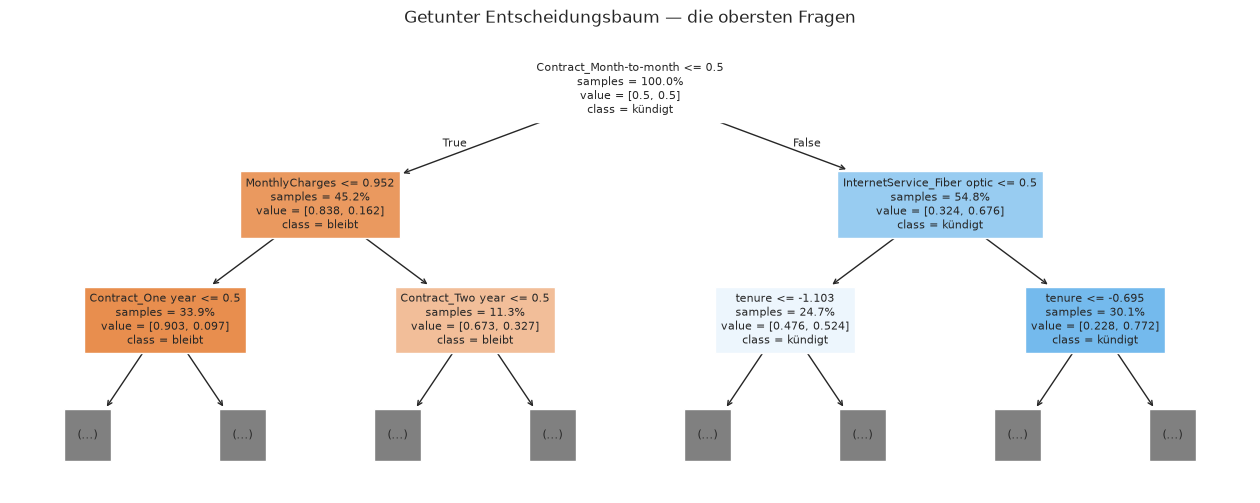

In [26]:
# Wie sieht der getunte Baum aus? Nur die obersten 2 Ebenen, sonst wird es unleserlich
bester_baum = getunt["Entscheidungsbaum"]
namen = [n.split("__", 1)[1] for n in bester_baum.named_steps["prep"].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(bester_baum.named_steps["model"], max_depth=2, feature_names=namen,
          class_names=["bleibt", "kündigt"], filled=True, impurity=False,
          proportion=True, fontsize=8, ax=ax)
ax.set_title("Getunter Entscheidungsbaum — die obersten Fragen")
plt.show()

**Interpretation:** Die erste Frage des Baums ist, ob ein Kunde einen Monatsvertrag hat (`Contract_Month-to-month`). Kunden mit Jahres- oder Zweijahresvertrag bleiben meistens, Kunden mit Monatsvertrag kündigen eher. Danach fragt der Baum nach Glasfaser und Kundendauer. Das passt zu dem, was in der EDA (Visualisierung 3 und 4) zu sehen war.

## 3.6 Vorhersagen auf dem Testset

Die getunten Modelle machen jetzt Vorhersagen für die 1407 Testkunden. `predict` gibt 0 oder 1 zurück, `predict_proba` die Kündigungswahrscheinlichkeit (wird für die ROC-AUC in Block 4 gebraucht).

In [27]:
# Beide getunten Modelle sagen die 1407 Testkunden vorher (erster Kontakt mit diesen Daten)
y_pred = {name: modell.predict(X_test) for name, modell in getunt.items()}
y_proba = {name: modell.predict_proba(X_test)[:, 1] for name, modell in getunt.items()}

for name in getunt:
    markiert_test = int((y_pred[name] == 1).sum())
    print(f"{name:18s} markiert {markiert_test} von {len(X_test)} Testkunden als «kündigt»")
print(f"{'tatsächlich':18s} kündigen {int(y_test.sum())} von {len(X_test)} Testkunden")

Log. Regression    markiert 592 von 1407 Testkunden als «kündigt»
Entscheidungsbaum  markiert 587 von 1407 Testkunden als «kündigt»
tatsächlich        kündigen 374 von 1407 Testkunden


**Ergebnis:** Die logistische Regression markiert 592 Kunden als «kündigt», der Baum 587. Tatsächlich kündigen im Testset 374 Kunden. Beide Modelle markieren also deutlich mehr Kunden, als es Kündiger gibt. Das ist die Folge von `balanced`. Wie gut die Vorhersagen sind, wird in Block 4 gemessen.

---
# Block 4: Evaluation und Fazit

## 4.1 Wahl der Metriken

Nur 26.6 % der Kunden kündigen. Ein Modell, das immer «bleibt» sagt, hätte schon 73 % Accuracy, würde aber keinen Kündiger finden. Deshalb werden diese Metriken verwendet:

- **Recall:** Anteil der echten Kündiger, die gefunden werden. Wichtigste Metrik, weil ein übersehener Kündiger am meisten kostet.
- **Precision:** Anteil der markierten Kunden, die wirklich kündigen. Zeigt, wie viele Angebote richtig eingesetzt werden.
- **F1:** Mittelwert aus Recall und Precision.
- **ROC-AUC:** Wie gut das Modell Kündiger und Nicht-Kündiger trennt, unabhängig von der Schwelle.
- **Accuracy:** Nur zum Vergleich mit der Baseline «niemand kündigt».

Die Funktion unten berechnet alle fünf Metriken auf einmal.

In [28]:
# Hilfsfunktion: berechnet alle fünf Metriken auf einmal
def metriken(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),   # braucht Wahrscheinlichkeiten, nicht 0/1
    }

## 4.2 Modellvergleich

Beide Modelle und die Baseline «niemand kündigt» werden auf dem Testset gemessen.

In [29]:
# Alle drei Varianten mit derselben Funktion messen, auf den 1407 Testkunden
ergebnisse = {
    "Baseline «niemand kündigt»": metriken(y_test, np.zeros(len(y_test), dtype=int),
                                           np.full(len(y_test), 0.5)),
    "Log. Regression": metriken(y_test, y_pred["Log. Regression"], y_proba["Log. Regression"]),
    "Entscheidungsbaum": metriken(y_test, y_pred["Entscheidungsbaum"], y_proba["Entscheidungsbaum"]),
}

print(f"Testset: {len(y_test)} Kunden, davon {int(y_test.sum())} echte Kündiger\n")
display(pd.DataFrame(ergebnisse).T.round(3))

Testset: 1407 Kunden, davon 374 echte Kündiger



,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline «niemand kündigt»,0.734,0.000,0.000,0.000,0.500
Log. Regression,0.729,0.493,0.781,0.605,0.832
Entscheidungsbaum,0.739,0.506,0.794,0.618,0.820


**Interpretation:** Die Baseline hat 73.4 % Accuracy, findet aber keinen einzigen Kündiger (Recall 0). Ihre ROC-AUC von 0.5 entspricht Raten.

Beide Modelle haben etwa die gleiche Accuracy wie die Baseline (0.729 und 0.739), finden aber rund 78 bis 79 % der Kündiger. Dafür liegt die Precision nur bei etwa 0.50, jedes zweite Angebot geht also an einen Kunden, der geblieben wäre.

Zwischen den beiden Modellen ist der Unterschied klein. Der Baum hat einen etwas höheren Recall (0.794 zu 0.781, das sind 5 Kunden), die logistische Regression eine höhere ROC-AUC (0.832 zu 0.820). Die Werte sind ähnlich wie in der Kreuzvalidierung (3.5), die Modelle funktionieren also auch auf neuen Daten.

Die Konfusionsmatrizen unten zeigen dasselbe in Anzahl Kunden.

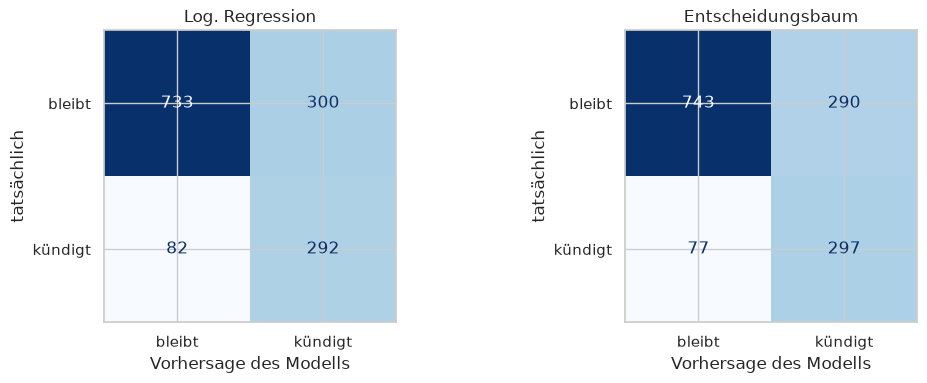

Log. Regression:
  richtig erkannte Kündiger (TP):   292
  übersehene Kündiger (FN):         82
  unnötige Angebote (FP):           300
  korrekt als «bleibt» erkannt (TN): 733
Entscheidungsbaum:
  richtig erkannte Kündiger (TP):   297
  übersehene Kündiger (FN):         77
  unnötige Angebote (FP):           290
  korrekt als «bleibt» erkannt (TN): 743


In [30]:
# Dieselben Ergebnisse als Konfusionsmatrix: wer wurde wie einsortiert?
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, getunt):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred[name], display_labels=["bleibt", "kündigt"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Vorhersage des Modells")
    ax.set_ylabel("tatsächlich")
plt.tight_layout()
plt.show()

# Die vier Felder nochmals in Worten
for name in getunt:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred[name]).ravel()
    print(f"{name}:")
    print(f"  richtig erkannte Kündiger (TP):   {tp}")
    print(f"  übersehene Kündiger (FN):         {fn}")
    print(f"  unnötige Angebote (FP):           {fp}")
    print(f"  korrekt als «bleibt» erkannt (TN): {tn}")

## 4.3 Interpretation

Aus der Konfusionsmatrix lässt sich einiges ablesen und ableiten. Die richtig erkannten Kündiger (Feld TP) ist schlussendlich doch auch der wichtigste Wert. Dieser will man so hoch wie möglich haben, da man diese Kunden eventuell halten kann durch ein Angebot. Das genaue Gegenteil ist das Feld TN, diese bleiben sowieso und bekommen auch kein Angebot anhand der Auswertung des Modells. Diese Zahl möchte man so hoch wie möglich haben.
Die übersehene Kündiger und unnötige Angeboten können leider nicht ganz vermieden werden. Durch das tuning der Modelle hat man diese Werte aber noch etwas korrigieren können.

Man muss aber auch bemerken, dass man hier keinerlei Analyse hat was passiert, wenn man dieses Angebot den Kunden schickt. Wie viele nehmen es wirklich an? Bei welcher Art von Kunden kommen diese Angebote am besten an? Das sind weiterhin offene Fragen und müssten anschliessend mit einer komplett neuen Analyse angegangen werden.

Unter dem Strich sind schlussendlich aber beide Modelle ziemlich ähnlich was die Resultate angeht. Es sind jeweils nur kleine Abweichungen, die den Unterschied ausmachen. Empfohlen wird aber trotzdem die logistische Regression, weil sie bei gleichem Recall die bessere ROC-AUC hat und damit die Rangliste besser sortiert. Die logistische Regression findet 292 von 374 Kündigern, übersiht 82 und verschickt 300 unnötige Angebote. Diese Quote ist vertretbar.



## 4.4 Beantwortung der Business-Frage

Die Business-Frage aus dem Kapitel 1.2 «Welche Bestandskunden werden im kommenden Abrechnungszyklus kündigen und sollen deshalb ein Halteangebot erhalten?» kann man jetzt versuchen zu beantworten.

Beide Modelle bieten eine Liste von Kunden, bei denen ein Halteangebot Sinn macht. Insgesamt kann man damit rechnen, dass ca. 78% der Kündiger gefunden werden. Man muss aber damit rechnen, dass ca. 50% der Angebote aber auch an Kunden gehen, die tatsächlich nicht Kündigen wollen. Ein Unternehmen könnte das Modell nehmen und die Kunden nach `predict_proba` sortieren und von oben her Angebote verschicken, bis das Budget aufgebraucht ist.
Das Modell kann keine konkreten Angaben geben zur Ursache der Kündigung. Die Nutzung ist auch nur für Halteangebote geeignet für den Moment, in dem man die Daten bekommt.

#TODO Die effektive Liste vom Anfang sortieren mit dem gelernten Zeugs und sodass man die Rangliste hat. Das wäre noch cool

## 4.5 Verbesserungsmöglichkeiten

**Weitere Daten** Diese Antwort klingt eigentlich zu einfach aber würde tatsächlich helfen. Wenn man einen grösseren Datensatz hat würden gewisse Fälle viel klarer sein. Zusätzlich zu mehr Reihen an Daten braucht man eigentlich auch noch weitere Spalten wie die Netzqualität, Störungen, Supportanfragen, Konkurrenzangebote etc. Mit diesen Informationen hätte man mehr Ursachen anstatt nur Muster.

**Zeitachse und Monitoring** Die Daten sind aktuell nur eine Momentaufnahme. Wenn man nach den ersten Halteangebote eine weitere Auswertung macht in der man auch die Wirksamkeit dieser Halteangebot sieht lassen sich viel genauere Ergebnisse produzieren. Man könnte dann ein A/B-Test durchführen (Hälfte der Risikokunden bekommt ein Angebot, Hälfte nicht) um zu zeigen, ob die Angebote wirken.

**Schwellenwert anpassen** Die Schwelle von 0.5 ist der Standard. Mit einer tieferen Schwelle findet man auch mehr Kündiger, aber verschickt auch mehr Angebote.

---
# 5 KI-Klassifizierung und Hilfsmittelverzeichnis

| Hilfsmittel | Version / Modell | Verwendungszweck | Umfang |
|---|---|---|---|
| Claude Code (Anthropic) | Opus 5 | Struktur des Notebooks, Code-Vorschläge für Pipeline, Tuning und Visualisierungen, Formulierungshilfe und Vereinfachung der Markdown-Texte, Vorlagen für Block 4 | durchgehend, jeweils geprüft und angepasst |
| scikit-learn Dokumentation | 1.x | Nachschlagen von Parametern (`ColumnTransformer`, `GridSearchCV`) | punktuell |

> **VORLAGE (vor der Abgabe löschen)**
>
> - Stimmt die Tabelle mit dem überein, was wirklich gemacht wurde? Fehlt ein Tool (z. B. ChatGPT, DeepL, Copilot)?
> - Eine Zeile oder einen kurzen Absatz ergänzen, was **selbst erarbeitet** wurde, z. B. Wahl der Business-Frage,
>   Entscheide bei der Bereinigung, Auswahl der Features, Interpretation und Fazit in Block 4.
> - Bei «Umfang» ehrlich unterscheiden: Was hat die KI geschrieben, was wurde nur geprüft oder umformuliert?

**Quellen**

- Telco Customer Churn Dataset, IBM Sample Data via Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Unterrichtsunterlagen Data Science, TEKO, S. Kessler: Einführung, Datenverarbeitung, Mathematische Werkzeuge, Modelle/Methoden/Algorithmen
- scikit-learn Dokumentation: https://scikit-learn.org
- Bibliotheken: pandas, NumPy, Matplotlib, seaborn, scikit-learn